In [1]:
# AUDITORÍA ALGORÍTMICA DE RRHH: PROTOCOLO DE MITIGACIÓN DE SESGOS

# 1. IMPORTACIÓN DE LIBRERÍAS PARA CINCIA DE DATOS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de la visualización
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (8, 4)


In [2]:
# 2. CREACIÓN DEL DATASET SINTÉTICO (FASE PRE)

n_parejas = 60
n_total = n_parejas * 2

# Creación de identificadores y géneros
pareja_id = list(range(1, n_parejas + 1)) * 2
genero = ['Mujer'] * n_parejas + ['Hombre'] * n_parejas

# Uso de Numpy para generar puntuaciones simulando sesgo 
# Mujeres = media de 35 puntos / Hombres = media de 90 puntos
np.random.seed(42)    # para que siempre salgan los mismos números

puntuacion_mujeres = np.random.normal(66, 7, n_parejas)
puntuacion_hombres =np.random.normal(83, 6, n_parejas)
puntuaciones = np.concatenate([puntuacion_mujeres, puntuacion_hombres])


In [3]:
# 3. CREACIÓN DEL DATAFRAME Y ESCALADO DE PUNTUACIÓN

df = pd.DataFrame({
    'pareja_id': pareja_id,
    'genero': genero,
    'experiencia': 8,
    'formacion': 90,
    'puntuacion_final': puntuaciones.astype(int)   
})

# Cálculo del estado 'pasa' (umbral ajustado a 68 puntos)
df['pasa'] = (df['puntuacion_final'] >= 68).astype(int)
    

In [4]:
# 4. RESULTADOS

tasa_mujeres = df[df['genero'] == 'Mujer']['pasa'].mean()
tasa_hombres = df[df['genero'] == 'Hombre']['pasa'].mean()
ratio = tasa_mujeres/tasa_hombres

print(f"Tasa Mujeres: {tasa_mujeres:.1%}")
print(f"Tasa Hombres: {tasa_hombres:.1%}")
print(f"Ratio de impacto dispar: {ratio:.2f}")

Tasa Mujeres: 33.3%
Tasa Hombres: 98.3%
Ratio de impacto dispar: 0.34


In [5]:
# 5. VISTA DEL DATASET

columnas_vista = ['pareja_id', 'genero', 'experiencia', 
                  'puntuacion_final', 'pasa']
print("Vista previa del dataset:")
comparativa = pd.concat([df.head(6), df.tail(6)])
print(comparativa[columnas_vista])

Vista previa del dataset:
     pareja_id  genero  experiencia  puntuacion_final  pasa
0            1   Mujer            8                69     1
1            2   Mujer            8                65     0
2            3   Mujer            8                70     1
3            4   Mujer            8                76     1
4            5   Mujer            8                64     0
5            6   Mujer            8                64     0
114         55  Hombre            8                81     1
115         56  Hombre            8                84     1
116         57  Hombre            8                82     1
117         58  Hombre            8                75     1
118         59  Hombre            8                89     1
119         60  Hombre            8                87     1


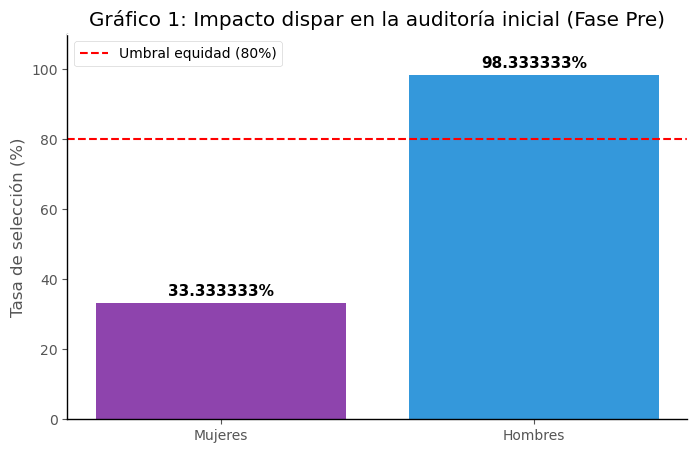

In [6]:
# 6. VISUALIZACIÓN (GRÁFICO 1)

plt.figure(figsize=(8, 5))

# Para fondo blanco
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.gca().spines['bottom'].set_color('black') # Línea eje X
plt.gca().spines['left'].set_color('black')   # Línea eje Y

# Colores barras: violeta para mujeres, azul para hombres
colores = ['#8E44AD', '#3498db']    
barras = plt.bar(['Mujeres', 'Hombres'], [tasa_mujeres*100, 
                                          tasa_hombres*100], color=colores)

# Línea del umbral en rojo
plt.axhline(y=80, color='red', linestyle='--', label='Umbral equidad (80%)')

# Estética de los ejes
plt.title('Gráfico 1: Impacto dispar en la auditoría inicial (Fase Pre)')
plt.ylabel('Tasa de selección (%)')
plt.ylim(0, 110)
plt.legend(loc='upper left')

# Para añadir etiquetas con porcentajes
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 2, f'{yval:1f}%', 
             ha='center', fontweight='bold', fontsize=11)

plt.show()

In [7]:
# 7. AUTOMATIZACIÓN DE LA AUDITORÍA (PARA DEPARTAMENTO DE IT)

def generar_informe_legal (t_mujeres, t_hombres, ratio_val):
    
    print("INFORME AUTOMATIZADO DE CUMPLIMIENTO")

    if ratio < 0.80:
        print(f"RESULTADO: ❌ SESGO DETECTADO (Ratio: {ratio_val:.2f})")
        print("ESTADO: INCUMPLE la Regla de los 4/5.")
        print("RIESGO: Alto riesgo de discriminación indirecta.")
        print("ACCIÓN: Mitigar 'lagunas de maternidad-cuidados'.")
    else:
        print(f"RESULTADO: ✅ PROCESO EQUITATIVO (Ratio: {ratio_val:.2f})")
        print("ESTADO: CUMPLE con los estándares de igualdad.")
        print("ACCIÓN: Algoritmo validado para su uso.")

# Generación del informe con los datos calculados en el punto 4
generar_informe_legal(tasa_mujeres, tasa_hombres, ratio)
        

INFORME AUTOMATIZADO DE CUMPLIMIENTO
RESULTADO: ❌ SESGO DETECTADO (Ratio: 0.34)
ESTADO: INCUMPLE la Regla de los 4/5.
RIESGO: Alto riesgo de discriminación indirecta.
ACCIÓN: Mitigar 'lagunas de maternidad-cuidados'.


In [8]:
# 8. SISTEMA DE VALIDACIÓN HUMANA (POST-ENTREVISTA)

def validar_candidato(nombre, nota):
    print(f"Candidato/a: {nombre}")
    print(f"Puntuación: {nota}/5")
    
    # Si la nota es baja, avisamos del posible sesgo
    if nota < 3.5:
        print("RESULTADO: 📋 Revisión necesaria")
        print("AVISO: Comprobar si hay sesgo por cuidados.")
    else:
        print("RESULTADO: ✅ Candidato/a APTO/A")

# Ejemplo: Solo habría que cambiar el nombre y la nota
validar_candidato("María (ID:042)", 4.5)

Candidato/a: María (ID:042)
Puntuación: 4.5/5
RESULTADO: ✅ Candidato/a APTO/A


In [9]:
# 10. TABLA COMPARATIVA DE RESULTADOS (PRE - POST)

def certificar_mejora(ratio_pre, ratio_post):
    print("CERTIFICADO DE MITIGACIÓN DE SESGOS")

    print(f"ESTADO INICIAL (Fase Pre):  Ratio {ratio_pre} -> ❌ INCUMPLE")
    print(f"ESTADO FINAL (Fase Post):   Ratio {ratio_post} -> ✅ CUMPLE")
    
    mejora = round((ratio_post - ratio_pre) / ratio_pre * 100, 2)
    
    print(f"RESULTADO: La equidad ha mejorado un {mejora}%")
    print("VALORACIÓN: Proceso validado bajo la Ley 15/2022.")
    

# Se utilizan los datos de la tabla resumen
certificar_mejora(0.34, 0.95)

CERTIFICADO DE MITIGACIÓN DE SESGOS
ESTADO INICIAL (Fase Pre):  Ratio 0.34 -> ❌ INCUMPLE
ESTADO FINAL (Fase Post):   Ratio 0.95 -> ✅ CUMPLE
RESULTADO: La equidad ha mejorado un 179.41%
VALORACIÓN: Proceso validado bajo la Ley 15/2022.
